In [1]:
import ee
import geemap.core as geemap
from datetime import datetime

ee.Authenticate()
ee.Initialize(project='sat-model-1')
print(ee.String('Hello from the Earth Engine servers!').getInfo())

Hello from the Earth Engine servers!


In [2]:
import pandas as pd

In [3]:
start_date = '2025-02-02'
end_date = '2025-02-04'

etopo1 = ee.Image("NOAA/NGDC/ETOPO1").select('bedrock')
        
oisst = ee.ImageCollection("NOAA/CDR/OISST/V2_1") \
    .filterDate(start_date, end_date) \
    .mean() \
    .select('sst')

In [4]:
def update_features(fc):
    def enrich(f):
        point = f.geometry()
        sst = oisst.sample(point, 5000).first().get('sst')
        
        buffer = point.buffer(1000)
        depth = etopo1.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=buffer,
            scale=1855
        ).get('bedrock')
        return f.set({
            'sst': sst,
            'depth': depth
        })
    return fc.map(enrich)

def update_sst_depth(df, fc):
    fc = update_features(fc)
    results = fc.getInfo()['features']
    id_to_values = {
        f['properties']['id']: (f['properties'].get('sst'),  f['properties'].get('depth'))
        for f in results
    }
    
    df['sst'] = [id_to_values.get(i, 0)[0] * 0.01 for i in df.index]
    df['depth'] = [- id_to_values.get(i, 0)[1] for i in df.index]
    
        
# def get_sst(image, features, index):
#     sampled = image.sampleRegions(
#         collection=features,
#         properties=['id'],
#         scale=5000,
#         geometries=False
#     )
#     results = sampled.getInfo()['features']
#     id_to_sst = {
#         f['properties']['id']: f['properties'].get('sst') 
#         for f in results
#     }
    
#     # Map back preserving original order
#     return [id_to_sst.get(i, 0) * 0.01 for i in index]

# def get_depth(image, features, index):
#     sampled = image.sampleRegions(
#         collection=features,
#         properties=['id'],
#         scale=1855,  # ETOPO1 native resolution
#         geometries=False,
#         tileScale=16  # Increase if hitting memory limits
#     )
    
#     results = sampled.getInfo()['features']
#     id_to_depth = {
#         f['properties']['id']: f['properties'].get('bedrock')
#         for f in results
#     }
    
#     return [id_to_depth.get(i) for i in index]


In [5]:
df = pd.read_csv('model.csv', sep=';')
features = [
    ee.Feature(
        ee.Geometry.Point([row['lon'], row['lat']]),
        {
            'id': idx,
            'code': row['code']
        }
    )
    for idx, row in df.iterrows()
]

fc = ee.FeatureCollection(features)

In [6]:
update_sst_depth(df, fc)
df['relative_depth'] = df['depth'] - df['fishing_depth']

In [ ]:
df.sample(5)

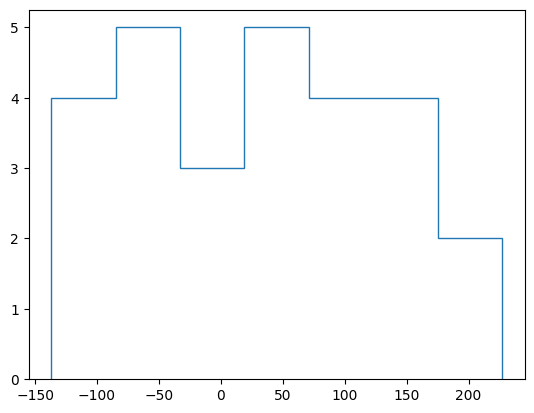

In [7]:
import matplotlib.pyplot as plt
import numpy as np
counts, bins = np.histogram(df['relative_depth'], 7)
plt.stairs(counts, bins);

In [8]:
def hsl_to_hex(h, s, l):
    """Convert HSL to hex color."""
    import colorsys
    r, g, b = colorsys.hls_to_rgb(h/360, l/100, s/100)
    return '#{:02x}{:02x}{:02x}'.format(int(r*255), int(g*255), int(b*255))

def get_distributed_colors(n):
    """Generate n visually distinct colors."""
    colors = []
    for i in range(n):
        hue = (i * 360 / n) % 360
        colors.append(hsl_to_hex(hue, 70, 50))
    return colors

In [14]:

m = geemap.Map()

unique_codes = df['code'].unique().tolist()
color_map = get_distributed_colors(len(unique_codes))

ee_colors = ee.Dictionary({str(k): v for k, v in zip(unique_codes, color_map)})

def styled_f(f):
    code_str = ee.Number(f.get('code')).format('%d')
    color = ee_colors.get(code_str)
    
    return f.set({
        'style': {
            'color': color,
            'pointSize': 8,
            'pointShape': 'circle'
        }
    })

fc_styled = fc.map(styled_f)

m.addLayer(fc_styled.style(styleProperty='style'), {}, 'Points')

In [18]:

vis_params = {
    'min': -6000,
    'max': 0,
    'palette': ['lightblue', 'blue', 'darkblue', 'black'][::-1]
}
    
m.add_layer(etopo1, vis_params, 'Глубина (Copernicus)', opacity=0.6)

m.setCenter(150, 56, 2) 

In [17]:
sst_vis = {
    'min': -10,
    'max': 10,
    'palette': [
        '440154',  # Фиолетовый (холодная)
        '31688e',
        '35b779',
        'fde725'   # Жёлтый (тёплая)
    ]
}

m.add_layer(oisst, sst_vis, 'Темература', opacity=0.6)

In [15]:
m

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
# Сохраняем результат измерений
df.to_csv('result.csv')